# E-Commerce Sales Data Analysis

This project analyzes sales performance of a retail superstore dataset to identify key revenue drivers and provide business insights.

## Problem Statement

The objective of this project is to analyze:
- Sales performance by region
- Segment contribution
- Monthly sales trends
- Shipping efficiency

And provide actionable business recommendations.

In [33]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train (1).csv


In [34]:
import pandas as pd

df = pd.read_csv("train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [35]:
# Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

# Create Shipping Delay column
df['Shipping Delay'] = (df['Ship Date'] - df['Order Date']).dt.days

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9800 non-null   int64         
 1   Order ID        9800 non-null   object        
 2   Order Date      9800 non-null   datetime64[ns]
 3   Ship Date       9800 non-null   datetime64[ns]
 4   Ship Mode       9800 non-null   object        
 5   Customer ID     9800 non-null   object        
 6   Customer Name   9800 non-null   object        
 7   Segment         9800 non-null   object        
 8   Country         9800 non-null   object        
 9   City            9800 non-null   object        
 10  State           9800 non-null   object        
 11  Postal Code     9789 non-null   float64       
 12  Region          9800 non-null   object        
 13  Product ID      9800 non-null   object        
 14  Category        9800 non-null   object        
 15  Sub-

In [36]:
df['Sales'].sum()

np.float64(2261536.7827000003)

In [37]:
df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

,Sales
Region,
West,710219.6845
East,669518.7260
Central,492646.9132
South,389151.4590


In [38]:
df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

,Sales
Segment,
Consumer,1.148061e+06
Corporate,6.884941e+05
Home Office,4.249822e+05


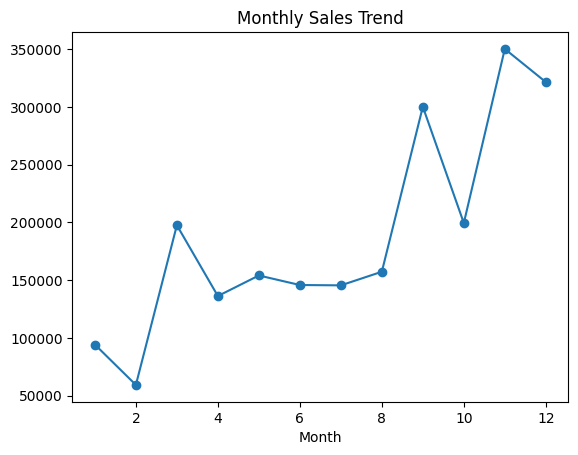

In [39]:
import matplotlib.pyplot as plt

df['Month'] = df['Order Date'].dt.month
monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.show()

## Key Insights

- Consumer segment contributes the highest revenue.
- Sales peak during Q4 (September–December).
- West region generates the highest sales.
- Average shipping delay is approximately 4 days.

## Business Recommendations

- Focus marketing efforts on the Consumer segment.
- Increase inventory before Q4 due to seasonal spike.
- Improve performance in low-performing regions.
- Maintain efficient shipping operations.